# 1.1 FK Receiver Function Benchmark

This notebook benchmarks **four FK propagators** against **PyRaysum** (primary reference) and **telewavesim** (secondary external) for teleseismic receiver-function modeling:

| Method | Implementation |
|--------|----------------|
| `haskell` | Thomson–Haskell propagator matrix (NumPy) |
| `haskell_numba` | Thomson–Haskell (Numba) |
| `kennett` | Kennett reflectivity (NumPy) |
| `kennett_numba` | Kennett reflectivity (Numba; default in `fk.engine`) |
| `telewavesim` | Telewavesim seismograms + **seispy iter** decon (precomputed) |
| `pyraysum` | PyRaysum seismograms + **seispy iter** decon (precomputed, reference) |

For each of **seven 1-D velocity models** we compute:

- **P-wave receiver functions (P-RF)** — radial deconvolved from vertical (`ux / uz`)
- **S-wave receiver functions (S-RF)** — vertical deconvolved from radial (`uz / ux`)

## Experiment goals

1. Verify that all four FK propagators agree with **PyRaysum** on synthetic RFs.
2. Compare FK/PyRaysum against **telewavesim** on the same models and decon settings.
3. Compare P-RF and S-RF sensitivity to crustal layering, polar ice/sediment cover, and LAB structure.
4. Document the workflow: FK simulation → seispy iterative decon → CC vs saved external references.

## Reference RFs (PyRaysum & telewavesim)

Both packages cannot run reliably in `GP245_Final`; reference RFs are **precomputed** in the
`pyraysum` conda environment and stored under
[`pyraysum_telewavesim_benchmark/output/pyraysum_rfs/`](pyraysum_telewavesim_benchmark/output/pyraysum_rfs/).
Regenerate with `python pyraysum_telewavesim_benchmark/run_benchmark.py` if needed.

## Models under test

| ID | Description |
|----|-------------|
| M1 | Single-layer crust (35 km) + mantle half-space |
| M2 | Two-layer crust (20 + 15 km) + mantle |
| M3 | Three-layer crust (5 + 15 + 15 km = 35 km) + mantle |
| M4 | 2 km ice + single crust + mantle |
| M5 | 2 km ice + 0.5 km sediment + single crust + mantle |
| M6 | Single crust + mantle lid + LVZ (LAB) |
| M7 | Two-layer crust + mantle lid + LVZ |

## Dependencies

```bash
pip install python-seispy
```

Core FDFK2D-Python modules: `fk.engine`, `fk.propagators`, `rf.decon`.


## 1. Setup and imports

Add the project root to `sys.path` so notebooks can import `fk` and `plots` modules.


In [1]:
import sys, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

sys.path.insert(0, os.path.abspath(".."))

from fk.model import FKLayerModel, density_from_vp_fdfk
from fk.source import RickerSource
from fk.engine import compute_fk_seismograms
from fk.geometry import rayp_deg_to_si
from rf import compute_prf, compute_srf

print(f"NumPy {np.__version__}")
print("All modules loaded OK")


NumPy 1.26.4
All modules loaded OK


## 2. Global simulation and deconvolution parameters

Shared settings:

- **P incidence:** ray parameter 4.798 s/deg (teleseismic P)
- **S incidence:** ray parameter 9.535 s/deg (Figure 2 half-space reference)
- **FK deconvolution:** seispy iterative time-domain method (Ligorria & Ammon, 1999); `f0=8.0`
- **External references:** same seispy iter decon on **PyRaysum** and **telewavesim** seismograms, loaded from `.npz` (`rf_radial`, `rf_radial_tws`)


In [2]:
# Time axis
DT = 0.025
NT = 2048
F0_SRC = 2.0

# Ray parameters (s/deg)
P_DEG = 4.798
S_DEG = 9.535
P_SI = rayp_deg_to_si(P_DEG)
S_SI = rayp_deg_to_si(S_DEG)

# RF deconvolution (FDFK2D plot_PRF.m / plot_SRF.m)
TSHIFT_P = 5.0
TSHIFT_S = 6.5
F0_RF = 8.0

ITMAX = 400
MINDERR = 0.001

# Single receiver at the surface
RCV_X = np.array([0.0])

# Plot windows
T_MAX_P = 30.0
T_MAX_S = 5.0

# FK propagator methods + precomputed external references
FK_METHODS = ["haskell", "haskell_numba", "kennett", "kennett_numba"]
EXTERNAL_METHODS = ["telewavesim", "pyraysum"]
REF_METHOD = "pyraysum"

METHOD_COLORS = {
    "haskell": "#0072B2",
    "haskell_numba": "#56B4E9",
    "kennett": "#009E73",
    "kennett_numba": "#D55E00",
    "telewavesim": "#CC79A7",
    "pyraysum": "#882255",
}

METHOD_LABELS = {
    "haskell": "Haskell (NumPy)",
    "haskell_numba": "Haskell (Numba)",
    "kennett": "Kennett (NumPy)",
    "kennett_numba": "Kennett (Numba)",
    "telewavesim": "Telewavesim",
    "pyraysum": "PyRaysum (ref)",
}

print(f"dt={DT} s, nt={NT}, T_max={DT*NT:.1f} s")
print(f"P: p={P_DEG} s/deg | S: p={S_DEG} s/deg")
print(f"P-RF decon: tshift={TSHIFT_P}, f0={F0_RF}")
print(f"S-RF decon: tshift={TSHIFT_S}, f0={F0_RF}")

PRS_RF_DIR = Path("pyraysum_telewavesim_benchmark/output/pyraysum_rfs")
if not PRS_RF_DIR.is_dir():
    raise FileNotFoundError(
        f"Reference RF directory not found: {PRS_RF_DIR.resolve()}\n"
        "Run: conda activate pyraysum && python pyraysum_telewavesim_benchmark/run_benchmark.py"
    )
print(f"External reference RFs: {PRS_RF_DIR.resolve()}")


dt=0.025 s, nt=2048, T_max=51.2 s
P: p=4.798 s/deg | S: p=9.535 s/deg
P-RF decon: tshift=5.0, f0=8.0
S-RF decon: tshift=6.5, f0=8.0
External reference RFs: /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/notebooks/pyraysum_telewavesim_benchmark/output/pyraysum_rfs


## 3. Helper functions and model catalog

Utility functions build FK models, load PyRaysum/telewavesim reference RFs, run FK backends, and plot multi-method overlays with CC analysis.


In [3]:
def _rho_list(vp_km_s):
    vp_m = np.array(vp_km_s, dtype=float) * 1000.0
    return density_from_vp_fdfk(vp_m).tolist()


def build_fk_model(vp_km_s, vs_km_s, z_top_km, rho=None):
    """Build FKLayerModel from km/s and km depth units."""
    vp = np.array(vp_km_s, dtype=float) * 1000.0
    vs = np.array(vs_km_s, dtype=float) * 1000.0
    z_top = np.array(z_top_km, dtype=float) * 1000.0
    if rho is None:
        rho = _rho_list(vp_km_s)
    else:
        rho = np.array(rho, dtype=float)
    return FKLayerModel.from_layers(vp, vs, z_top, rho=rho)


def _layer_thickness_km(z_top_km):
    z = np.array(z_top_km, dtype=float)
    thick = np.diff(np.append(z, np.inf))
    thick[-1] = 0.0
    return thick.tolist()


MANTLE = {"vp": 8.0, "vs": 4.45}
LAB_LID = {"vp": 8.1, "vs": 4.5, "thick": 65.0}
LAB_LVZ = {"vp": 7.6, "vs": 4.2}

MODELS = {
    "M1": {
        "title": "M1: Single-layer crust (35 km)",
        "description": (
            "Classic continental Moho: one crustal layer over a uniform mantle half-space. "
            "Same structure as FDFK2D test2 / validation Model 1."
        ),
        "vp": [6.0, MANTLE["vp"]],
        "vs": [3.45, MANTLE["vs"]],
        "z_top": [0.0, 35.0],
        "phases_p": ["Ps", "PpPs", "PpSs"],
        "phases_s": ["Sp"],
    },
    "M2": {
        "title": "M2: Two-layer crust (20 + 15 km)",
        "description": (
            "Upper and lower crust with a mid-crustal velocity contrast before the Moho."
        ),
        "vp": [6.0, 6.5, MANTLE["vp"]],
        "vs": [3.45, 3.75, MANTLE["vs"]],
        "z_top": [0.0, 20.0, 35.0],
        "phases_p": ["Ps", "PpPs"],
        "phases_s": ["Sp"],
    },
    "M3": {
        "title": "M3: Three-layer crust (5 + 15 + 15 km)",
        "description": (
            "Sedimentary/upper/middle/lower crust stack; total crust thickness 35 km "
            "for direct comparison with M1 Moho depth."
        ),
        "vp": [4.0, 6.0, 6.8, MANTLE["vp"]],
        "vs": [2.3, 3.45, 3.9, MANTLE["vs"]],
        "z_top": [0.0, 5.0, 20.0, 35.0],
        "phases_p": ["Ps", "PpPs"],
        "phases_s": ["Sp"],
    },
    "M4": {
        "title": "M4: 2 km ice + single crust",
        "description": (
            "Polar-style overburden: low-velocity ice (Vp 4.0, Vs 2.0 km/s) over "
            "standard continental crust."
        ),
        "vp": [4.0, 6.0, MANTLE["vp"]],
        "vs": [2.0, 3.45, MANTLE["vs"]],
        "z_top": [0.0, 2.0, 37.0],
        "phases_p": ["Ps"],
        "phases_s": ["Sp"],
    },
    "M5": {
        "title": "M5: 2 km ice + 0.5 km sediment + single crust",
        "description": (
            "Ice cap with soft marine/basin sediment (Vp 2.8, Vs 1.6) before "
            "35 km continental crust."
        ),
        "vp": [4.0, 2.8, 6.0, MANTLE["vp"]],
        "vs": [2.0, 1.6, 3.45, MANTLE["vs"]],
        "z_top": [0.0, 2.0, 2.5, 37.5],
        "phases_p": ["Ps"],
        "phases_s": ["Sp"],
    },
    "M6": {
        "title": "M6: Single crust + LAB (lid + LVZ)",
        "description": (
            "35 km crust, 65 km mantle lid, and a low-velocity asthenosphere half-space "
            "(validation Model 3 / FDFK2D test3 structure)."
        ),
        "vp": [6.0, LAB_LID["vp"], LAB_LVZ["vp"]],
        "vs": [3.45, LAB_LID["vs"], LAB_LVZ["vs"]],
        "z_top": [0.0, 35.0, 100.0],
        "phases_p": ["Ps", "PpPs"],
        "phases_s": ["Sp"],
    },
    "M7": {
        "title": "M7: Two-layer crust + LAB",
        "description": (
            "M2 crustal stack underlain by the same mantle lid + LVZ as M6."
        ),
        "vp": [6.0, 6.5, LAB_LID["vp"], LAB_LVZ["vp"]],
        "vs": [3.45, 3.75, LAB_LID["vs"], LAB_LVZ["vs"]],
        "z_top": [0.0, 20.0, 35.0, 100.0],
        "phases_p": ["Ps", "PpPs"],
        "phases_s": ["Sp"],
    },
}


def make_fk_model(spec):
    """Return FKLayerModel from a MODELS entry."""
    rho = _rho_list(spec["vp"])
    return build_fk_model(spec["vp"], spec["vs"], spec["z_top"], rho=rho)


def vertical_slowness(v, p):
    return float(np.sqrt(max(1.0 / v ** 2 - p ** 2, 0.0)))


def predicted_phase_lags(model, p_si, incidence):
    """Plane-wave phase lags (s) relative to direct arrival."""
    lags = {}
    n = model.n_finite_layers
    if n == 0:
        return lags
    qp = [vertical_slowness(model.vp[i], p_si) for i in range(n)]
    qs = [vertical_slowness(model.vs[i], p_si) for i in range(n)]
    h = [model.thickness[i] for i in range(n)]
    tp = sum(h[i] * qp[i] for i in range(n))
    ts = sum(h[i] * qs[i] for i in range(n))
    if incidence == "P":
        lags["Ps"] = ts - tp
        lags["PpPs"] = ts + tp
        lags["PpSs"] = 2.0 * ts
        lags["PpPp"] = 2.0 * tp
    else:
        lags["Sp"] = tp - ts
        lags["SpPs"] = tp + ts
        lags["SpPp"] = 2.0 * tp
    return lags



def load_pyraysum_rf(model_id, incidence):
    """Load precomputed PyRaysum radial RF from archive (.npz).

    Uses ``rf_radial`` with ``decon_method='iter'`` (seispy on PyRaysum RTZ
    seismograms) — same decon pipeline as the FK methods.
    """
    path = PRS_RF_DIR / f"{model_id}_{incidence}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Regenerate with run_benchmark.py in the pyraysum env."
        )
    d = np.load(path)
    if "decon_method" in d.files and str(d["decon_method"]) != "iter":
        raise ValueError(
            f"{path.name}: expected decon_method='iter', got {d['decon_method']!r}. "
            "Re-run pyraysum_telewavesim_benchmark/run_benchmark.py."
        )
    rms = float(d["rms"]) if "rms" in d.files else 0.0
    return d["t_rf"], d["rf_radial"], rms


def load_telewavesim_rf(model_id, incidence):
    """Load precomputed telewavesim radial RF (seispy iter) from the same archive."""
    path = PRS_RF_DIR / f"{model_id}_{incidence}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Regenerate with run_benchmark.py in the pyraysum env."
        )
    d = np.load(path)
    if "rf_radial_tws" not in d.files:
        raise ValueError(
            f"{path.name}: missing rf_radial_tws. "
            "Re-run pyraysum_telewavesim_benchmark/run_benchmark.py."
        )
    rms = float(d["rms_tws"]) if "rms_tws" in d.files else 0.0
    return d["t_rf_tws"], d["rf_radial_tws"], rms


def compute_fk_rf(model_fk, fk_method, incidence, p_deg):
    """FK seismograms + RF for one propagator backend."""
    source = RickerSource(f0=F0_SRC, incidence=incidence)
    res = compute_fk_seismograms(
        model_fk, source, RCV_X, DT, NT,
        p_deg=p_deg, x0_plane=0.0, z_init=model_fk.z_top[-1],
        method=fk_method,
    )
    tshift = TSHIFT_P if incidence == "P" else TSHIFT_S
    decon_kwargs = dict(
        tshift=tshift, f0=F0_RF, itmax=ITMAX, minderr=MINDERR,
    )
    if incidence == "P":
        rfs, t_rf, rms_arr = compute_prf(res.ux, res.uz, DT, **decon_kwargs)
    else:
        rfs, t_rf, rms_arr = compute_srf(res.ux, res.uz, DT, **decon_kwargs)
    return t_rf, rfs[0], float(rms_arr[0]), res


def run_all_methods(model_fk, model_id, incidence):
    """Run four FK backends + load PyRaysum/telewavesim references."""
    p_deg = P_DEG if incidence == "P" else S_DEG
    results = {}
    for m in FK_METHODS:
        print(f"    FK {m} ...")
        t_rf, rf, rms, _ = compute_fk_rf(model_fk, m, incidence, p_deg)
        results[m] = (t_rf, rf, rms)
        print(f"      RMS={rms:.4f}")
    print("    telewavesim (loaded) ...")
    t_rf, rf, rms = load_telewavesim_rf(model_id, incidence)
    results["telewavesim"] = (t_rf, rf, rms)
    print(f"      loaded {model_id}_{incidence}.npz  RMS={rms:.4f}")
    print("    pyraysum (loaded) ...")
    t_rf, rf, rms = load_pyraysum_rf(model_id, incidence)
    results[REF_METHOD] = (t_rf, rf, rms)
    print(f"      loaded {model_id}_{incidence}.npz  RMS={rms:.4f}")
    return results



def _interp_rf(t_src, rf_src, t_grid):
    return np.interp(t_grid, t_src, rf_src, left=0.0, right=0.0)


def waveform_cc(a, b):
    """Max normalized lag cross-correlation."""
    a = a - a.mean()
    b = b - b.mean()
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    if norm < 1e-30:
        return 0.0
    return float(np.max(np.correlate(a, b, mode="full")) / norm)


def cc_vs_reference(results, ref=None, t_min=-1.0, t_max=30.0):
    """CC and RMS table vs reference method (common time grid via interpolation)."""
    if ref is None:
        ref = REF_METHOD
    t_ref, rf_ref, _ = results[ref]
    t_grid = np.arange(t_min, t_max + 1e-9, DT)
    rf_ref_i = _interp_rf(t_ref, rf_ref, t_grid)
    rows = []
    for name, (t, rf, rms) in results.items():
        if name == ref:
            continue
        rf_i = _interp_rf(t, rf, t_grid)
        cc = waveform_cc(rf_i, rf_ref_i)
        rows.append((name, cc, rms))
    return rows


def print_cc_table(results, phase, t_max):
    """Print CC vs PyRaysum and vs Telewavesim, plus RMS for each FK method."""
    t_min = -1.0
    rows_prs = cc_vs_reference(results, ref=REF_METHOD, t_min=t_min, t_max=t_max)
    rows_tws = cc_vs_reference(results, ref="telewavesim", t_min=t_min, t_max=t_max)
    cc_prs_map = {name: (cc, rms) for name, cc, rms in rows_prs}
    cc_tws_map = {name: (cc, rms) for name, cc, rms in rows_tws}
    print(f"  Cross-correlation ({phase}-RF, window [{t_min}, {t_max}] s):")
    print(f"    {'Method':22s}  {'CC vs PRS':>12s}  {'CC vs TWS':>12s}  {'RMS':>8s}")
    for m in FK_METHODS:
        prs_cc, rms = cc_prs_map.get(m, (float("nan"), 0))
        tws_cc, _ = cc_tws_map.get(m, (float("nan"), 0))
        print(f"    {METHOD_LABELS[m]:22s}  {prs_cc:12.6f}  {tws_cc:12.6f}  {rms:8.4f}")
    prs_vs_tws, _ = cc_tws_map.get(REF_METHOD, (float("nan"), 0))
    print(f"    {'PyRaysum (ref)':22s}  {'1.000000':>12s}  {prs_vs_tws:12.6f}")
    tws_vs_prs, _ = cc_prs_map.get("telewavesim", (float("nan"), 0))
    print(f"    {'Telewavesim':22s}  {tws_vs_prs:12.6f}  {'1.000000':>12s}")


# Line draw order: bottom (thickest) -> top (thinnest) for overlay comparison
PLOT_METHOD_ORDER = FK_METHODS + EXTERNAL_METHODS
PLOT_LW = {
    "haskell": 6,
    "haskell_numba": 5,
    "kennett": 4,
    "kennett_numba": 3,
    "telewavesim": 2.5,
    "pyraysum": 2,
}
PLOT_ZORDER = {name: i + 2 for i, name in enumerate(PLOT_METHOD_ORDER)}


def _phases_in_window(lags, phase_names, xmin, xmax):
    """Return (name, lag) pairs whose lag falls inside the plot x-range."""
    if not phase_names:
        return []
    visible = []
    for pname in phase_names:
        lag = lags.get(pname)
        if lag is None:
            continue
        if xmin <= lag <= xmax:
            visible.append((pname, lag))
    return visible


def plot_rf_multimethod(results, title, phase, t_max, model_fk=None, p_si=None, phase_names=None):
    """Single figure: bold colored RF traces for all methods."""
    tshift = TSHIFT_P if phase == "P" else TSHIFT_S
    xmin, xmax = -tshift, t_max

    fig, ax = plt.subplots(figsize=(12, 5))
    for name in PLOT_METHOD_ORDER:
        t, rf, _ = results[name]
        ax.plot(
            t, rf,
            color=METHOD_COLORS[name],
            lw=PLOT_LW[name],
            zorder=PLOT_ZORDER[name],
            label=METHOD_LABELS[name],
            solid_capstyle="round",
        )
    ax.axvline(0, color="gray", ls="--", lw=1.0, zorder=1, label="Direct arrival")

    if model_fk is not None and p_si is not None and phase_names:
        lags = predicted_phase_lags(model_fk, p_si, phase)
        visible = _phases_in_window(lags, phase_names, xmin, xmax)
        ymax = np.max(np.abs([results[n][1] for n in results])) * 1.05
        for pname, lag in visible:
            ax.axvline(lag, color="gray", ls=":", lw=1.2, alpha=0.75, zorder=1.5)
            ax.text(
                lag, ymax * 0.88, pname,
                fontsize=12, ha="center", va="top", color="0.25", zorder=10,
            )

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("Amplitude", fontsize=14)
    ax.set_title(f"{title} — {phase}-wave RF", fontsize=15)
    ax.tick_params(labelsize=12)
    ax.legend(loc="upper right", fontsize=12, framealpha=0.9)
    ax.grid(alpha=0.3, zorder=0)
    rows_prs = cc_vs_reference(results, ref=REF_METHOD, t_min=-1.0, t_max=t_max)
    rows_tws = cc_vs_reference(results, ref="telewavesim", t_min=-1.0, t_max=t_max)
    cc_prs = "  ".join(f"{k}: {cc:.3f}" for k, cc, _ in rows_prs if k in FK_METHODS)
    cc_tws = "  ".join(f"{k}: {cc:.3f}" for k, cc, _ in rows_tws if k in FK_METHODS)
    ax.text(
        0.02, 0.08, f"CC vs PRS: {cc_prs}", transform=ax.transAxes,
        fontsize=10, va="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )
    ax.text(
        0.02, 0.02, f"CC vs TWS: {cc_tws}", transform=ax.transAxes,
        fontsize=10, va="bottom",
        bbox=dict(boxstyle="round", facecolor="lightskyblue", alpha=0.5),
    )
    fig.tight_layout()
    from IPython.display import display
    display(fig)
    plt.close(fig)


def analyze_model(model_id, store=None):
    """Build model, compute P/S RFs for all methods, plot and print CC."""
    spec = MODELS[model_id]
    print("=" * 72)
    print(spec["title"])
    print(spec["description"])
    model_fk = make_fk_model(spec)
    print(model_fk.summary())

    out = {"id": model_id, "title": spec["title"], "P": {}, "S": {}}
    for incidence in ("P", "S"):
        print(f"\nComputing {incidence}-wave receiver functions ...")
        results = run_all_methods(model_fk, model_id, incidence)
        t_max = T_MAX_P if incidence == "P" else T_MAX_S
        print_cc_table(results, incidence, t_max)
        p_si = P_SI if incidence == "P" else S_SI
        phase_names = spec["phases_p"] if incidence == "P" else spec["phases_s"]
        plot_rf_multimethod(
            results, spec["title"], incidence, t_max,
            model_fk=model_fk, p_si=p_si, phase_names=phase_names,
        )
        out[incidence]["results"] = results
        out[incidence]["cc"] = {
            name: cc for name, cc, _ in cc_vs_reference(
                results, ref=REF_METHOD, t_min=-1.0, t_max=t_max
            )
        }
        out[incidence]["cc_tws"] = {
            name: cc for name, cc, _ in cc_vs_reference(
                results, ref="telewavesim", t_min=-1.0, t_max=t_max
            )
        }
    if store is not None:
        store[model_id] = out
    return out


print(f"Model catalog: {[k for k in MODELS if not k.startswith('_')]}")


Model catalog: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7']


## 4. Single-layer crust (35 km + mantle)

Expect a clear Moho **Ps** pulse on P-RF and **Sp** on S-RF.

Layer parameters are defined in `MODELS['M1']` (see Section 3).


M1: Single-layer crust (35 km)
Classic continental Moho: one crustal layer over a uniform mantle half-space. Same structure as FDFK2D test2 / validation Model 1.
  idx     Vp       Vs      rho     z_top   thick
    0   6000.0   3450.0   2529.0      0.0  35000.0
    1   8000.0   4450.0   3253.6  35000.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.3399
    FK haskell_numba ...


      RMS=0.3399
    FK kennett ...
      RMS=0.3399
    FK kennett_numba ...
      RMS=0.3399
    telewavesim (loaded) ...
      loaded M1_P.npz  RMS=0.3006
    pyraysum (loaded) ...
      loaded M1_P.npz  RMS=0.3162
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.997223      0.998125    0.3399
    Haskell (Numba)             0.997223      0.998125    0.3399
    Kennett (NumPy)             0.997223      0.998125    0.3399
    Kennett (Numba)             0.997223      0.998125    0.3399
    PyRaysum (ref)              1.000000      0.996883
    Telewavesim                 0.996883      1.000000


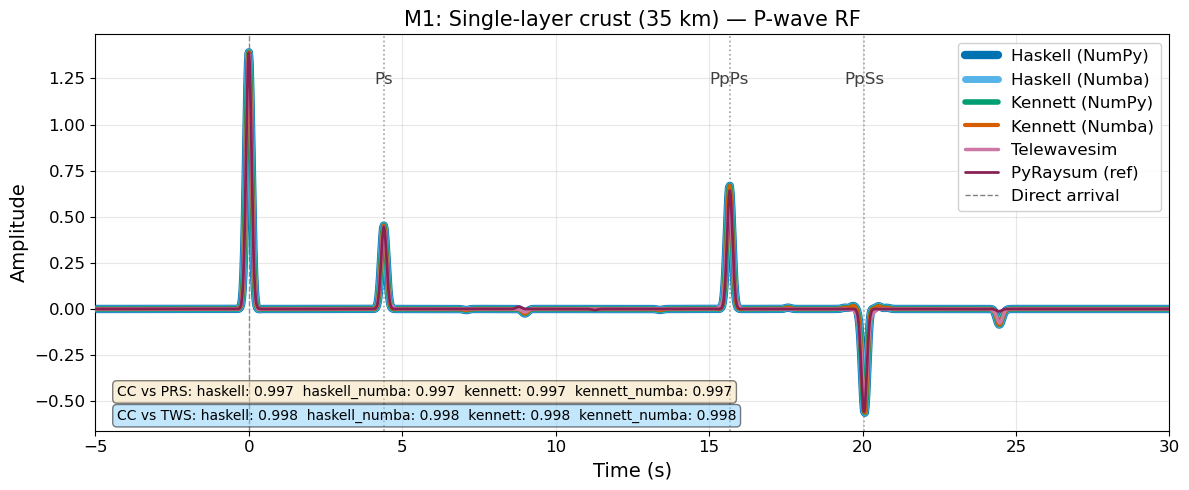


Computing S-wave receiver functions ...
    FK haskell ...
      RMS=0.3097
    FK haskell_numba ...
      RMS=0.3097
    FK kennett ...
      RMS=0.3097
    FK kennett_numba ...
      RMS=0.3097
    telewavesim (loaded) ...
      loaded M1_S.npz  RMS=0.2929
    pyraysum (loaded) ...
      loaded M1_S.npz  RMS=0.5684
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.999752      1.000000    0.3097
    Haskell (Numba)             0.999752      1.000000    0.3097
    Kennett (NumPy)             0.999752      1.000000    0.3097
    Kennett (Numba)             0.999752      1.000000    0.3097
    PyRaysum (ref)              1.000000      0.999736
    Telewavesim                 0.999736      1.000000


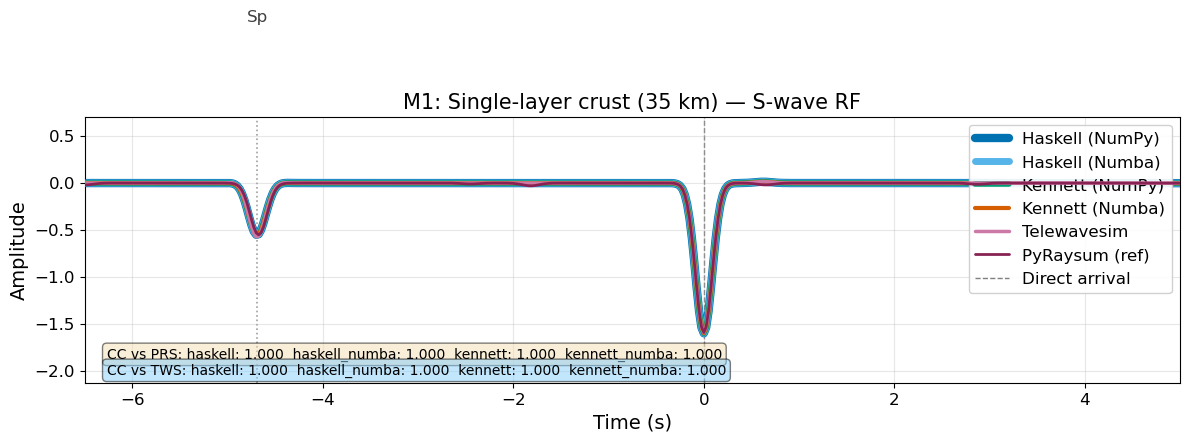

{'id': 'M1',
 'title': 'M1: Single-layer crust (35 km)',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.05216007e-15, 3.02882065e-15, 2.37266458e-15, ...,
           2.38698650e-16, 1.44492249e-15, 2.51853598e-15]),
    0.33985396786613203),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.01502917e-15, 2.96835032e-15, 2.35887310e-15, ...,
           1.79289208e-16, 1.45340956e-15, 2.48989214e-15]),
    0.33985396786613203),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.03624683e-15, 2.98956798e-15, 2.38751694e-15, ...,
           2.20663641e-16, 1.45977485e-15, 2.47503978e-15]),
    0.339853967866132),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([2.99805504e-15, 2.95508929e-15, 2.35781222e-15, ...,
           2.03689515e-16, 1.44067896e-15, 2.47185713e-15]),
    0.339853967866132),
   'tel

In [4]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M1", store=ALL_RESULTS)


## 5. Two-layer crust (20 + 15 km)

Mid-crustal velocity contrast adds converted phases before Moho **Ps**.

Layer parameters are defined in `MODELS['M2']` (see Section 3).


M2: Two-layer crust (20 + 15 km)
Upper and lower crust with a mid-crustal velocity contrast before the Moho.
  idx     Vp       Vs      rho     z_top   thick
    0   6000.0   3450.0   2529.0      0.0  20000.0
    1   6500.0   3750.0   2710.1  20000.0  15000.0
    2   8000.0   4450.0   3253.6  35000.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.2319
    FK haskell_numba ...
      RMS=0.2319
    FK kennett ...


      RMS=0.2319
    FK kennett_numba ...
      RMS=0.2319
    telewavesim (loaded) ...
      loaded M2_P.npz  RMS=0.2044
    pyraysum (loaded) ...
      loaded M2_P.npz  RMS=0.2207
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.997404      0.996988    0.2319
    Haskell (Numba)             0.997404      0.996988    0.2319
    Kennett (NumPy)             0.997404      0.996988    0.2319
    Kennett (Numba)             0.997404      0.996988    0.2319
    PyRaysum (ref)              1.000000      0.996885
    Telewavesim                 0.996885      1.000000


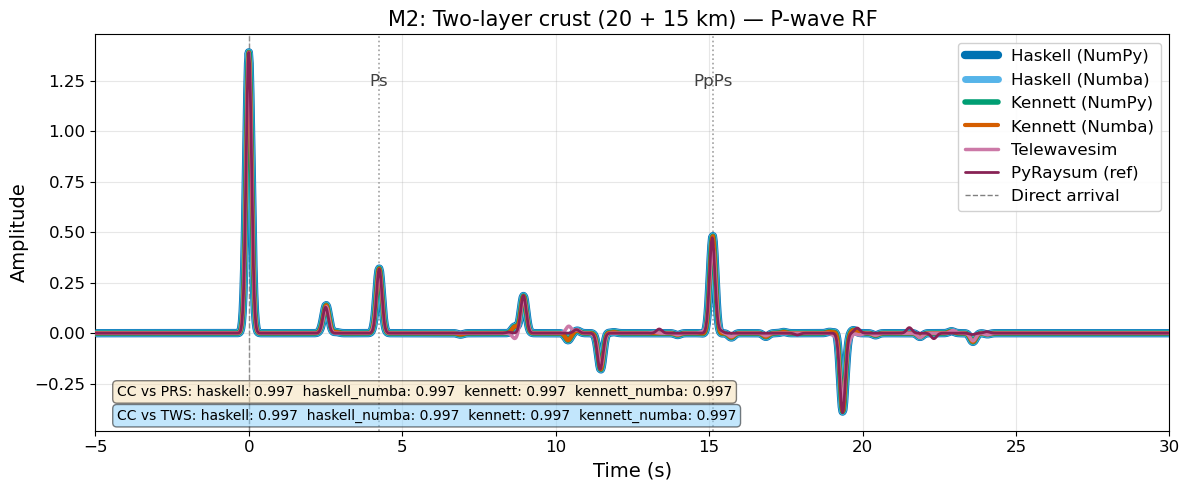


Computing S-wave receiver functions ...
    FK haskell ...
      RMS=0.1977
    FK haskell_numba ...
      RMS=0.1977
    FK kennett ...


      RMS=0.1977
    FK kennett_numba ...
      RMS=0.1977
    telewavesim (loaded) ...
      loaded M2_S.npz  RMS=0.1885
    pyraysum (loaded) ...
      loaded M2_S.npz  RMS=0.5593
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.987224      0.998999    0.1977
    Haskell (Numba)             0.987224      0.998999    0.1977
    Kennett (NumPy)             0.987224      0.998999    0.1977
    Kennett (Numba)             0.987224      0.998999    0.1977
    PyRaysum (ref)              1.000000      0.991499
    Telewavesim                 0.991499      1.000000


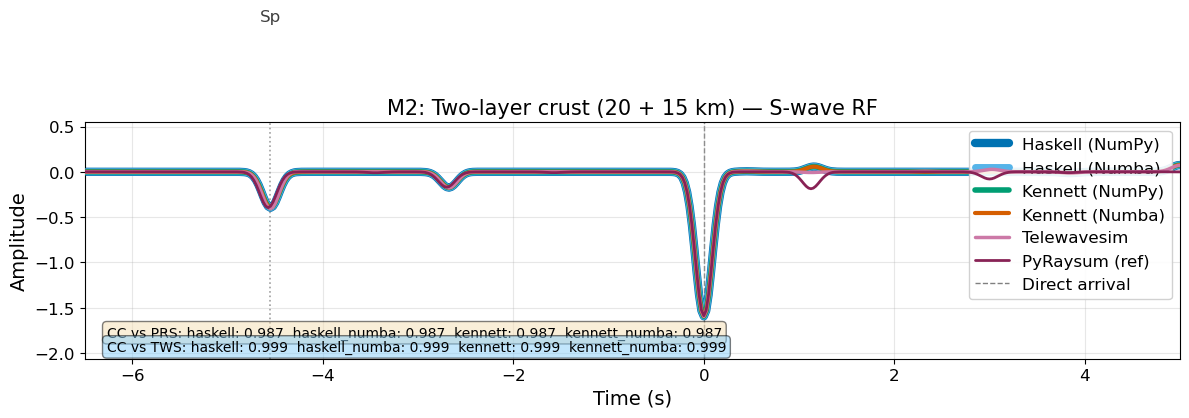

{'id': 'M2',
 'title': 'M2: Two-layer crust (20 + 15 km)',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-1.18288442e-16, -4.66788471e-16, -9.59038131e-16, ...,
            4.43979489e-16,  2.55142335e-16,  1.22531974e-16]),
    0.23190455602381926),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-1.03436082e-16, -4.59362291e-16, -9.60629455e-16, ...,
            4.71562444e-16,  2.76359992e-16,  9.89273293e-17]),
    0.23190455602381926),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-1.08740496e-16, -4.35227205e-16, -9.53203275e-16, ...,
            4.97554075e-16,  2.94395001e-16,  1.32875582e-16]),
    0.23190455602381924),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-1.09005717e-16, -4.31248894e-16, -9.46307536e-16, ...,
            4.75275534e-16,  2.83786173e-16,  1.33140802e-16]),
   

In [5]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M2", store=ALL_RESULTS)


## 6. Three-layer crust (5 + 15 + 15 km)

Shallow low-velocity layer produces near-surface multiples; Moho depth matches M1.

Layer parameters are defined in `MODELS['M3']` (see Section 3).


M3: Three-layer crust (5 + 15 + 15 km)
Sedimentary/upper/middle/lower crust stack; total crust thickness 35 km for direct comparison with M1 Moho depth.
  idx     Vp       Vs      rho     z_top   thick
    0   4000.0   2300.0   1804.3      0.0   5000.0
    1   6000.0   3450.0   2529.0   5000.0  15000.0
    2   6800.0   3900.0   2818.8  20000.0  15000.0
    3   8000.0   4450.0   3253.6  35000.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.6773
    FK haskell_numba ...


      RMS=0.6773
    FK kennett ...


      RMS=0.6773
    FK kennett_numba ...
      RMS=0.6773
    telewavesim (loaded) ...
      loaded M3_P.npz  RMS=0.6455
    pyraysum (loaded) ...
      loaded M3_P.npz  RMS=0.5674
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.920627      0.945299    0.6773
    Haskell (Numba)             0.920627      0.945299    0.6773
    Kennett (NumPy)             0.920627      0.945299    0.6773
    Kennett (Numba)             0.920627      0.945299    0.6773
    PyRaysum (ref)              1.000000      0.909039
    Telewavesim                 0.909039      1.000000


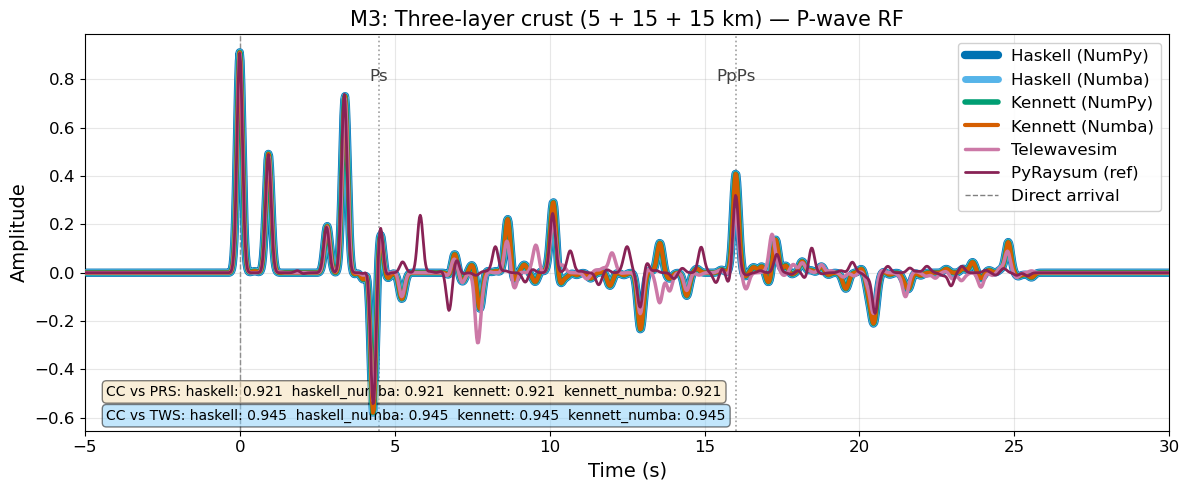


Computing S-wave receiver functions ...
    FK haskell ...
      RMS=0.6447
    FK haskell_numba ...
      RMS=0.6447
    FK kennett ...
      RMS=0.6447
    FK kennett_numba ...
      RMS=0.6447
    telewavesim (loaded) ...
      loaded M3_S.npz  RMS=0.6726
    pyraysum (loaded) ...
      loaded M3_S.npz  RMS=0.4820
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.559831      0.994962    0.6447
    Haskell (Numba)             0.559831      0.994962    0.6447
    Kennett (NumPy)             0.559831      0.994962    0.6447
    Kennett (Numba)             0.559831      0.994962    0.6447
    PyRaysum (ref)              1.000000      0.538443
    Telewavesim                 0.538443      1.000000


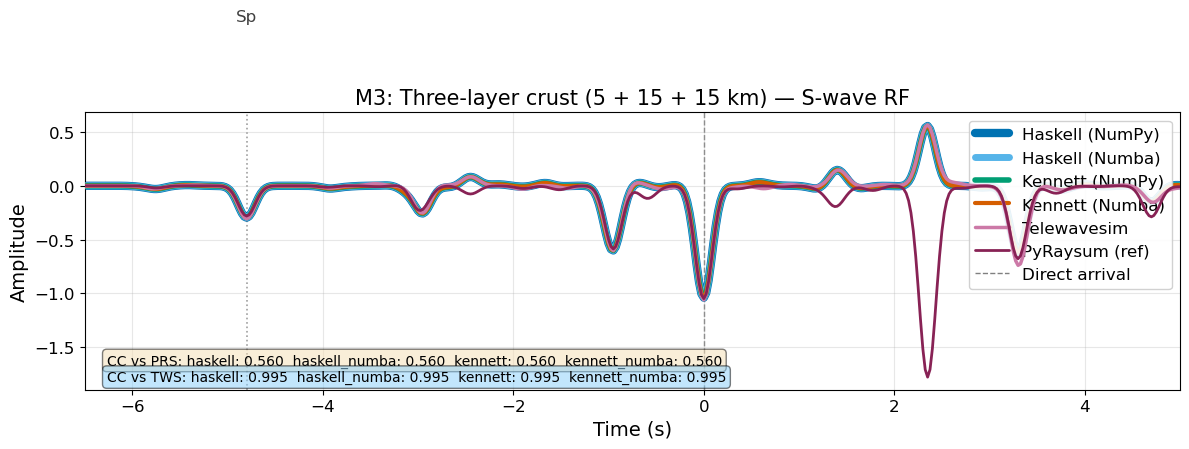

{'id': 'M3',
 'title': 'M3: Three-layer crust (5 + 15 + 15 km)',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-6.28042670e-16, -1.35793010e-15, -2.38910826e-15, ...,
            2.20663641e-16,  5.94094417e-17, -1.86715388e-16]),
    0.6772790386458594),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-5.77120291e-16, -1.33671244e-15, -2.40608239e-15, ...,
            2.54611893e-16,  1.18818883e-16, -1.52767136e-16]),
    0.6772790386458593),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-5.98337949e-16, -1.35793010e-15, -2.42093475e-15, ...,
            2.37637767e-16,  4.24353155e-17, -1.86715388e-16]),
    0.6772790386458595),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-6.19555607e-16, -1.37066069e-15, -2.40396062e-15, ...,
            2.71586019e-16,  2.54611893e-17, -1.78228325e-16]),


In [6]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M3", store=ALL_RESULTS)


## 7. 2 km ice + single crust

Low-velocity ice generates strong near-surface reverberations on both P- and S-RFs.

Layer parameters are defined in `MODELS['M4']` (see Section 3).


M4: 2 km ice + single crust
Polar-style overburden: low-velocity ice (Vp 4.0, Vs 2.0 km/s) over standard continental crust.
  idx     Vp       Vs      rho     z_top   thick
    0   4000.0   2000.0   1804.3      0.0   2000.0
    1   6000.0   3450.0   2529.0   2000.0  35000.0
    2   8000.0   4450.0   3253.6  37000.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.8233
    FK haskell_numba ...
      RMS=0.8233
    FK kennett ...
      RMS=0.8233
    FK kennett_numba ...
      RMS=0.8233
    telewavesim (loaded) ...
      loaded M4_P.npz  RMS=0.8155
    pyraysum (loaded) ...
      loaded M4_P.npz  RMS=0.7244
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.831101      0.905311    0.8233
    Haskell (Numba)             0.831101      0.905311    0.8233
    Kennett (NumPy)             0.831101      0.905311    0.8233
    Kennett (Numba)             0.8

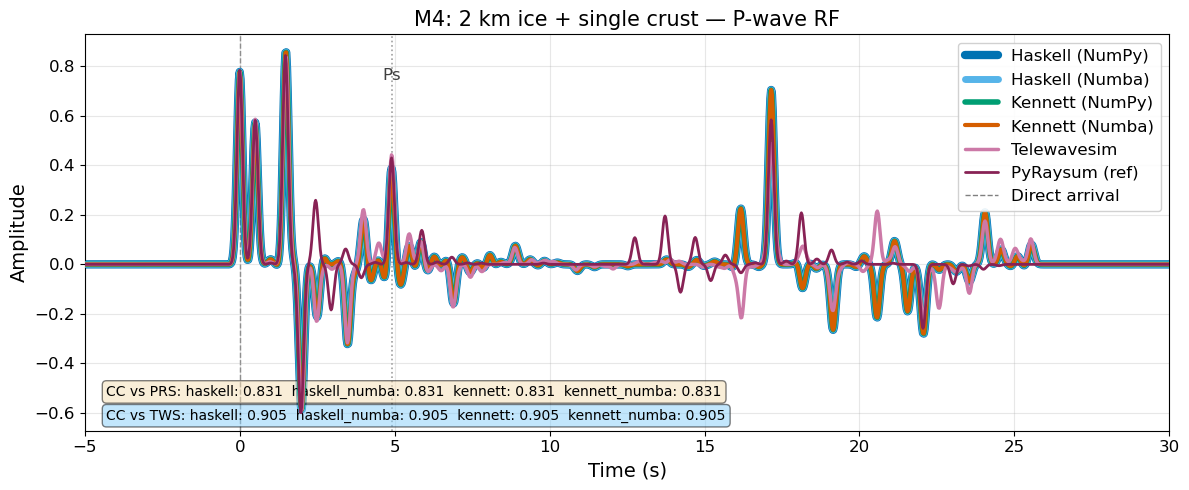


Computing S-wave receiver functions ...
    FK haskell ...
      RMS=0.7775
    FK haskell_numba ...
      RMS=0.7775
    FK kennett ...
      RMS=0.7775
    FK kennett_numba ...
      RMS=0.7775
    telewavesim (loaded) ...
      loaded M4_S.npz  RMS=0.8296
    pyraysum (loaded) ...
      loaded M4_S.npz  RMS=0.5399
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.655662      0.992477    0.7775
    Haskell (Numba)             0.655662      0.992477    0.7775
    Kennett (NumPy)             0.655662      0.992477    0.7775
    Kennett (Numba)             0.655662      0.992477    0.7775
    PyRaysum (ref)              1.000000      0.646021
    Telewavesim                 0.646021      1.000000


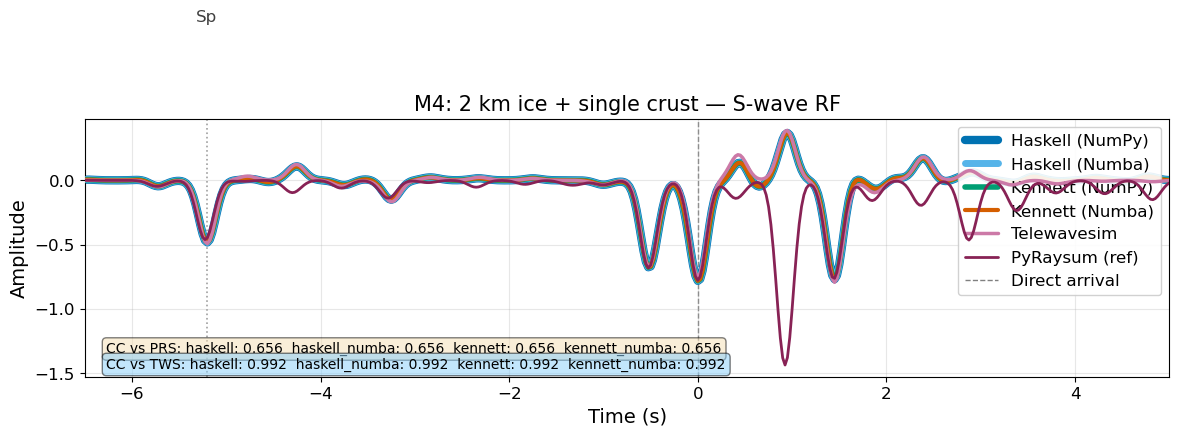

{'id': 'M4',
 'title': 'M4: 2 km ice + single crust',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-4.59998820e-15, -4.85460010e-15, -4.79519066e-15, ...,
           -2.85165320e-15, -3.49667000e-15, -4.03984204e-15]),
    0.8232838955793305),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-4.49814345e-15, -4.82065184e-15, -4.87157422e-15, ...,
           -2.83467908e-15, -3.47969587e-15, -4.03984204e-15]),
    0.8232838955793309),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-4.56603995e-15, -4.78670359e-15, -4.82065184e-15, ...,
           -2.81770495e-15, -3.49667000e-15, -4.00589379e-15]),
    0.8232838955793307),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([-4.53209170e-15, -4.71880709e-15, -4.79519066e-15, ...,
           -2.86862733e-15, -3.53061825e-15, -4.02286791e-15]),
    0.82328

In [7]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M4", store=ALL_RESULTS)


## 8. 2 km ice + 0.5 km sediment + crust

Soft sediment adds short-period multiples beneath the ice layer.

Layer parameters are defined in `MODELS['M5']` (see Section 3).


M5: 2 km ice + 0.5 km sediment + single crust
Ice cap with soft marine/basin sediment (Vp 2.8, Vs 1.6) before 35 km continental crust.
  idx     Vp       Vs      rho     z_top   thick
    0   4000.0   2000.0   1804.3      0.0   2000.0
    1   2800.0   1600.0   1369.6   2000.0    500.0
    2   6000.0   3450.0   2529.0   2500.0  35000.0
    3   8000.0   4450.0   3253.6  37500.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.7392
    FK haskell_numba ...
      RMS=0.7392
    FK kennett ...
      RMS=0.7392
    FK kennett_numba ...
      RMS=0.7392
    telewavesim (loaded) ...
      loaded M5_P.npz  RMS=0.7442
    pyraysum (loaded) ...
      loaded M5_P.npz  RMS=0.7651
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.528315      0.738903    0.7392
    Haskell (Numba)             0.528315      0.738903    0.7392
    Kennett (NumPy)             0.5283

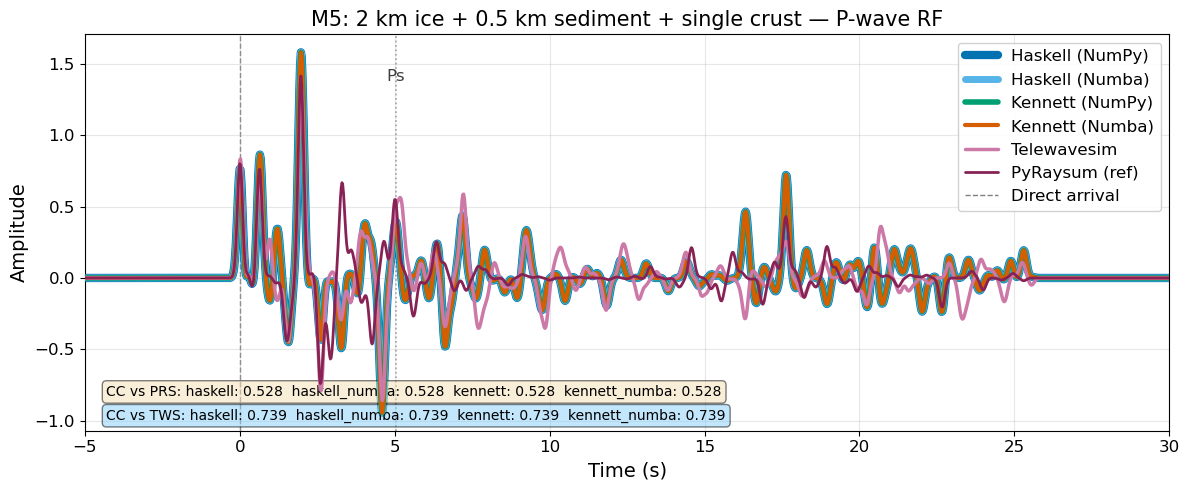


Computing S-wave receiver functions ...
    FK haskell ...
      RMS=0.7653
    FK haskell_numba ...
      RMS=0.7653
    FK kennett ...
      RMS=0.7653
    FK kennett_numba ...


      RMS=0.7653
    telewavesim (loaded) ...
      loaded M5_S.npz  RMS=0.2045
    pyraysum (loaded) ...
      loaded M5_S.npz  RMS=0.6762
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.692790      0.915640    0.7653
    Haskell (Numba)             0.692790      0.915640    0.7653
    Kennett (NumPy)             0.692790      0.915640    0.7653
    Kennett (Numba)             0.692790      0.915640    0.7653
    PyRaysum (ref)              1.000000      0.790005
    Telewavesim                 0.790005      1.000000


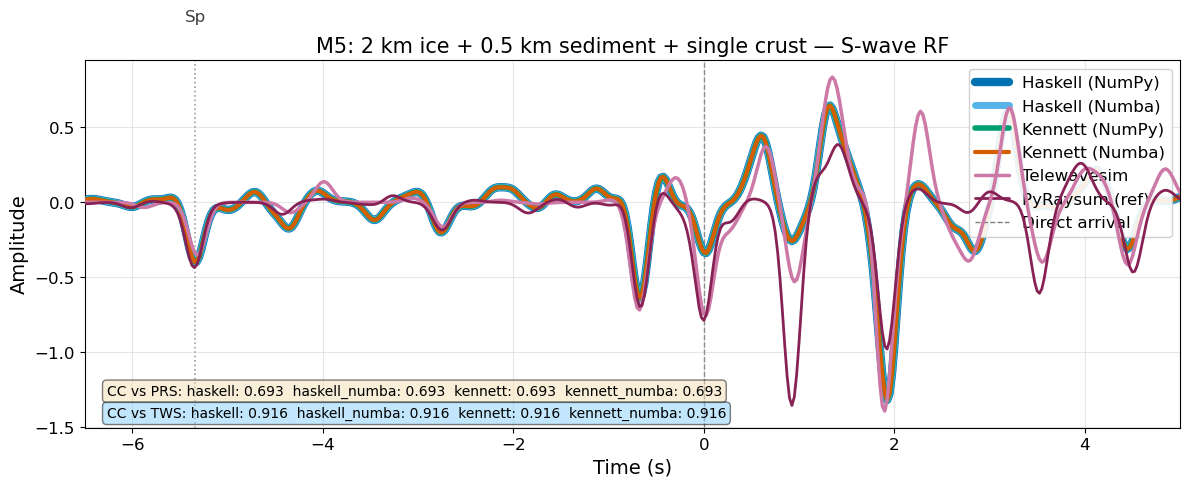

{'id': 'M5',
 'title': 'M5: 2 km ice + 0.5 km sediment + single crust',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([5.02009783e-15, 4.90127894e-15, 4.36235044e-15, ...,
           3.00442034e-15, 4.10773854e-15, 4.67637177e-15]),
    0.739159515873322),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([5.01797606e-15, 4.84611303e-15, 4.44722107e-15, ...,
           2.97047209e-15, 4.02286791e-15, 4.75275534e-15]),
    0.7391595158733218),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([4.96917545e-15, 4.83338244e-15, 4.41327282e-15, ...,
           2.97047209e-15, 4.12471267e-15, 4.73578121e-15]),
    0.7391595158733217),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([5.03070666e-15, 4.89703541e-15, 4.37932456e-15, ...,
           2.98744621e-15, 4.05681616e-15, 4.74426828e-15]),
    0.739159515873

In [8]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M5", store=ALL_RESULTS)


## 9. Single crust + LAB

Mantle lid and LVZ produce deep converted phases on S-RF. The Moho **Sp** arrival (~−12 s for this model) lies **outside** the default S-RF plot window [−6.5, 5] s and is therefore not annotated.

Layer parameters are defined in `MODELS['M6']` (see Section 3).


M6: Single crust + LAB (lid + LVZ)
35 km crust, 65 km mantle lid, and a low-velocity asthenosphere half-space (validation Model 3 / FDFK2D test3 structure).
  idx     Vp       Vs      rho     z_top   thick
    0   6000.0   3450.0   2529.0      0.0  35000.0
    1   8100.0   4500.0   3289.9  35000.0  65000.0
    2   7600.0   4200.0   3108.7 100000.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.3817
    FK haskell_numba ...
      RMS=0.3817
    FK kennett ...
      RMS=0.3817
    FK kennett_numba ...
      RMS=0.3817
    telewavesim (loaded) ...
      loaded M6_P.npz  RMS=0.3347
    pyraysum (loaded) ...
      loaded M6_P.npz  RMS=0.3432
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.995227      0.997188    0.3817
    Haskell (Numba)             0.995227      0.997188    0.3817
    Kennett (NumPy)             0.995227      0.997188    0.3817
  

      RMS=0.3441
    FK haskell_numba ...
      RMS=0.3441
    FK kennett ...
      RMS=0.3441
    FK kennett_numba ...
      RMS=0.3441
    telewavesim (loaded) ...
      loaded M6_S.npz  RMS=0.3326
    pyraysum (loaded) ...
      loaded M6_S.npz  RMS=0.5729
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.999736      0.999986    0.3441
    Haskell (Numba)             0.999736      0.999986    0.3441
    Kennett (NumPy)             0.999736      0.999986    0.3441
    Kennett (Numba)             0.999736      0.999986    0.3441
    PyRaysum (ref)              1.000000      0.999688
    Telewavesim                 0.999688      1.000000


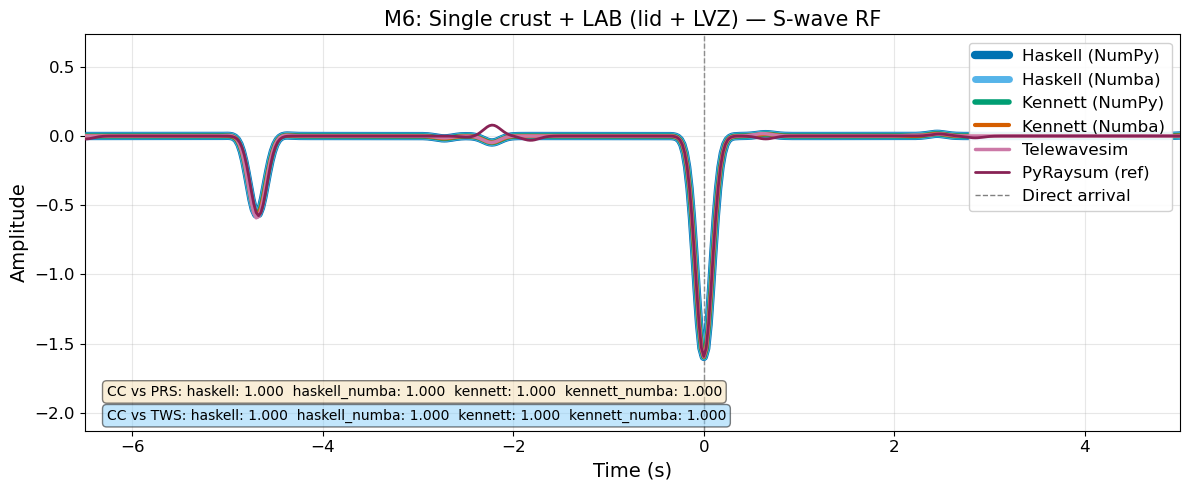

{'id': 'M6',
 'title': 'M6: Single crust + LAB (lid + LVZ)',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.19113573e-15, 3.19140095e-15, 2.55487122e-15, ...,
           2.58855425e-16, 1.56957623e-15, 2.63523309e-15]),
    0.3816610987107852),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.21394471e-15, 3.19458360e-15, 2.56892791e-15, ...,
           2.46124830e-16, 1.59026345e-15, 2.66122473e-15]),
    0.38166109871078535),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.22190133e-15, 3.18105734e-15, 2.58616726e-15, ...,
           2.51959686e-16, 1.57647197e-15, 2.63523309e-15]),
    0.38166109871078546),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([3.22110567e-15, 3.16249189e-15, 2.58775859e-15, ...,
           2.47716154e-16, 1.59132433e-15, 2.61878941e-15]),
    0.38166109871078535),


In [9]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M6", store=ALL_RESULTS)


## 10. Two-layer crust + LAB

Combines M2 crustal structure with M6 upper-mantle discontinuities. Moho **Sp** (~−12 s) is outside the S-RF plot window and is omitted from phase markers.

Layer parameters are defined in `MODELS['M7']` (see Section 3).


M7: Two-layer crust + LAB
M2 crustal stack underlain by the same mantle lid + LVZ as M6.
  idx     Vp       Vs      rho     z_top   thick
    0   6000.0   3450.0   2529.0      0.0  20000.0
    1   6500.0   3750.0   2710.1  20000.0  15000.0
    2   8100.0   4500.0   3289.9  35000.0  65000.0
    3   7600.0   4200.0   3108.7 100000.0 inf (half-space)

Computing P-wave receiver functions ...
    FK haskell ...
      RMS=0.2742
    FK haskell_numba ...
      RMS=0.2742
    FK kennett ...
      RMS=0.2742
    FK kennett_numba ...
      RMS=0.2742
    telewavesim (loaded) ...
      loaded M7_P.npz  RMS=0.2387
    pyraysum (loaded) ...
      loaded M7_P.npz  RMS=0.2485
  Cross-correlation (P-RF, window [-1.0, 30.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.995304      0.996374    0.2742
    Haskell (Numba)             0.995304      0.996374    0.2742
    Kennett (NumPy)             0.995304      0.996374    0.2742
    Kennett (Numba)

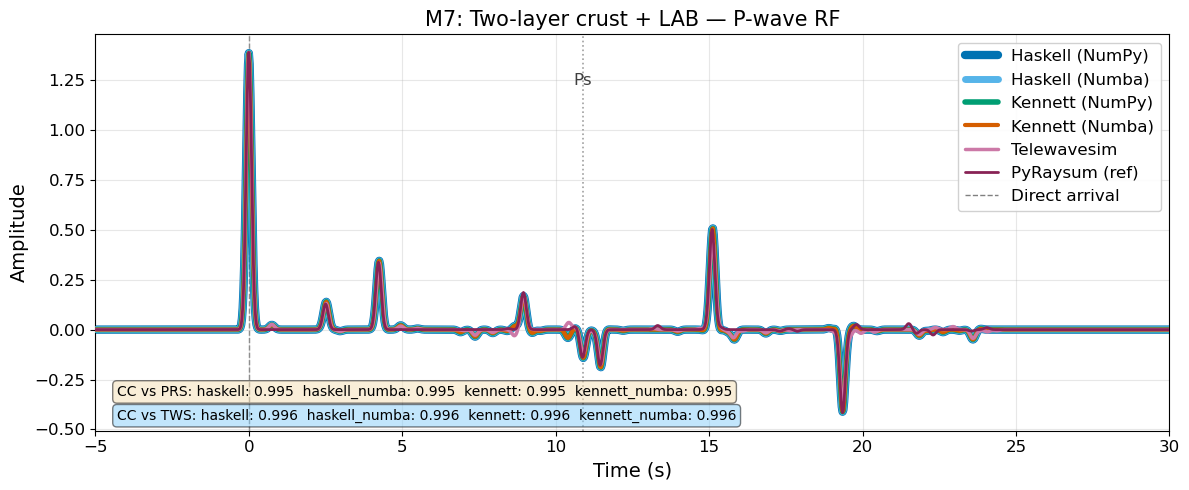


Computing S-wave receiver functions ...
    FK haskell ...
      RMS=0.2361
    FK haskell_numba ...
      RMS=0.2361
    FK kennett ...
      RMS=0.2361
    FK kennett_numba ...
      RMS=0.2361
    telewavesim (loaded) ...
      loaded M7_S.npz  RMS=0.2293
    pyraysum (loaded) ...
      loaded M7_S.npz  RMS=0.5634
  Cross-correlation (S-RF, window [-1.0, 5.0] s):
    Method                     CC vs PRS     CC vs TWS       RMS
    Haskell (NumPy)             0.985365      0.998875    0.2361
    Haskell (Numba)             0.985365      0.998875    0.2361
    Kennett (NumPy)             0.985365      0.998875    0.2361
    Kennett (Numba)             0.985365      0.998875    0.2361
    PyRaysum (ref)              1.000000      0.990181
    Telewavesim                 0.990181      1.000000


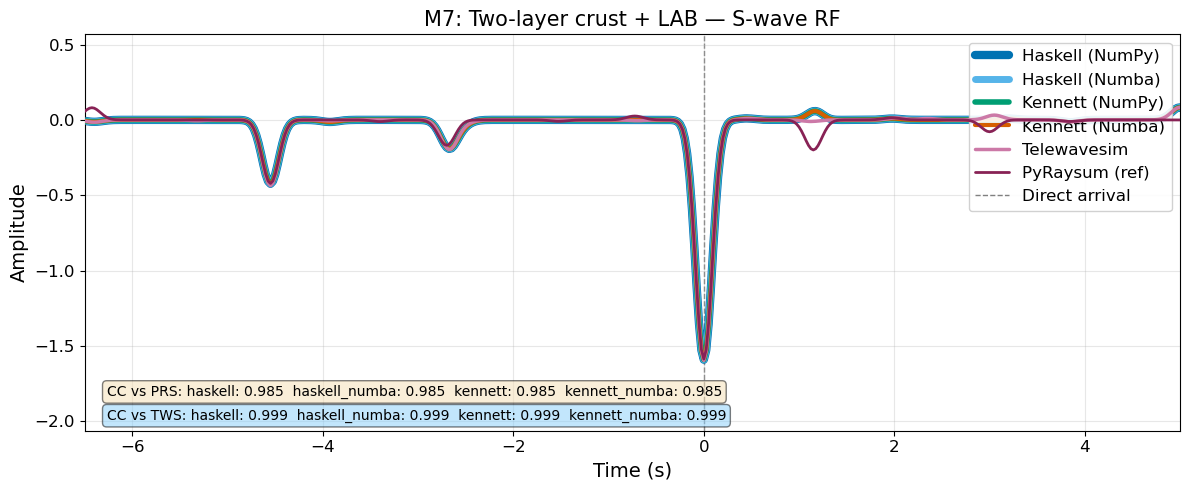

{'id': 'M7',
 'title': 'M7: Two-layer crust + LAB',
 'P': {'results': {'haskell': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([ 1.33671244e-16, -1.78228325e-16, -7.48452878e-16, ...,
            6.19555607e-16,  4.94371426e-16,  3.68656804e-16]),
    0.27418409107227637),
   'haskell_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([ 1.57010667e-16, -1.67619496e-16, -7.50044202e-16, ...,
            6.48199445e-16,  5.04980255e-16,  3.68922024e-16]),
    0.2741840910722763),
   'kennett': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([ 1.65497731e-16, -1.87245830e-16, -7.30948310e-16, ...,
            6.21146931e-16,  5.18241291e-16,  3.46643484e-16]),
    0.27418409107227637),
   'kennett_numba': (array([-5.   , -4.975, -4.95 , ..., 46.125, 46.15 , 46.175]),
    array([ 1.31549478e-16, -1.81941415e-16, -7.35191842e-16, ...,
            6.28042670e-16,  5.25667471e-16,  3.58047975e-16]),
    0.27418

In [10]:
ALL_RESULTS = globals().get('ALL_RESULTS', {})
analyze_model("M7", store=ALL_RESULTS)


## 11. Summary

Aggregate cross-correlation (CC) of each FK propagator against both **PyRaysum** (ray method) and **telewavesim** (full-wave propagator matrix) across all models.

Two CC reference frames are shown:
- **CC vs PyRaysum**: FK agreement with the ray-theory code (`mults=2`, first-order free-surface multiples only).
- **CC vs Telewavesim**: FK agreement with an independent full-wave propagator matrix method (all-order multiples, like FK).


P-wave RF — CC vs PyRaysum
Model               haskell   haskell_numba         kennett   kennett_numba     telewavesim
----------------------------------------------------------------------------------------
M1                 0.997223        0.997223        0.997223        0.997223        0.996883
M2                 0.997404        0.997404        0.997404        0.997404        0.996885
M3                 0.920627        0.920627        0.920627        0.920627        0.909039
M4                 0.831101        0.831101        0.831101        0.831101        0.837718
M5                 0.528315        0.528315        0.528315        0.528315        0.543249
M6                 0.995227        0.995227        0.995227        0.995227        0.995131
M7                 0.995304        0.995304        0.995304        0.995304        0.994410

S-wave RF — CC vs PyRaysum
Model               haskell   haskell_numba         kennett   kennett_numba     telewavesim
----------------------------

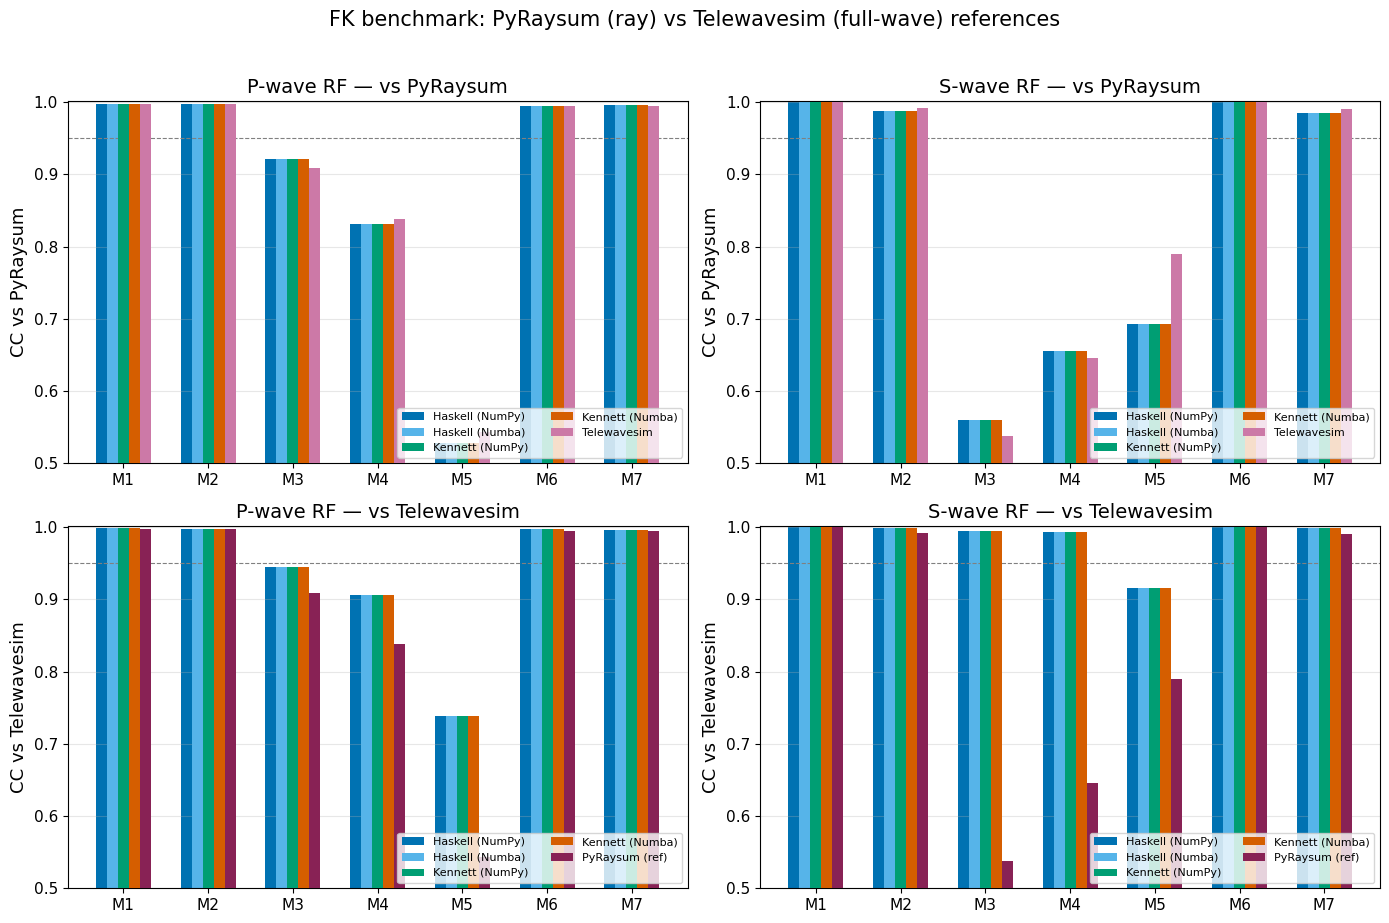

In [11]:
SUMMARY_METHODS = FK_METHODS + ["telewavesim"]

if 'ALL_RESULTS' not in globals():
    ALL_RESULTS = {}

if len(ALL_RESULTS) < 7:
    ALL_RESULTS = {}
    for mid in MODELS:
        analyze_model(mid, store=ALL_RESULTS)

# --- Table 1: CC vs PyRaysum ---
print("=" * 88)
print("P-wave RF — CC vs PyRaysum")
print(f"{'Model':<12}", "  ".join(f"{m:>14s}" for m in SUMMARY_METHODS))
print("-" * 88)
for mid, data in ALL_RESULTS.items():
    cc_row = [data["P"]["cc"].get(m, float("nan")) for m in SUMMARY_METHODS]
    print(f"{mid:<12}", "  ".join(f"{c:14.6f}" for c in cc_row))

print()
print("S-wave RF — CC vs PyRaysum")
print(f"{'Model':<12}", "  ".join(f"{m:>14s}" for m in SUMMARY_METHODS))
print("-" * 88)
for mid, data in ALL_RESULTS.items():
    cc_row = [data["S"]["cc"].get(m, float("nan")) for m in SUMMARY_METHODS]
    print(f"{mid:<12}", "  ".join(f"{c:14.6f}" for c in cc_row))

# --- Table 2: CC vs Telewavesim ---
SUMMARY_METHODS_TWS = FK_METHODS + [REF_METHOD]
print()
print("=" * 88)
print("P-wave RF — CC vs Telewavesim")
print(f"{'Model':<12}", "  ".join(f"{m:>14s}" for m in SUMMARY_METHODS_TWS))
print("-" * 88)
for mid, data in ALL_RESULTS.items():
    cc_row = [data["P"]["cc_tws"].get(m, float("nan")) for m in SUMMARY_METHODS_TWS]
    print(f"{mid:<12}", "  ".join(f"{c:14.6f}" for c in cc_row))

print()
print("S-wave RF — CC vs Telewavesim")
print(f"{'Model':<12}", "  ".join(f"{m:>14s}" for m in SUMMARY_METHODS_TWS))
print("-" * 88)
for mid, data in ALL_RESULTS.items():
    cc_row = [data["S"]["cc_tws"].get(m, float("nan")) for m in SUMMARY_METHODS_TWS]
    print(f"{mid:<12}", "  ".join(f"{c:14.6f}" for c in cc_row))

# --- Bar charts: CC vs PyRaysum (top row) and CC vs Telewavesim (bottom row) ---
from IPython.display import display

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
mids = list(ALL_RESULTS.keys())
x = np.arange(len(mids))
width = 0.13

for col, phase in enumerate(("P", "S")):
    # Row 0: CC vs PyRaysum
    ax = axes[0, col]
    for i, method in enumerate(SUMMARY_METHODS):
        vals = [ALL_RESULTS[m][phase]["cc"].get(method, 0) for m in mids]
        ax.bar(x + i * width, vals, width, label=METHOD_LABELS[method],
               color=METHOD_COLORS[method], zorder=i + 1)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(mids, fontsize=12)
    ax.set_ylim(0.5, 1.001)
    ax.set_ylabel("CC vs PyRaysum", fontsize=13)
    ax.set_title(f"{phase}-wave RF — vs PyRaysum", fontsize=14)
    ax.tick_params(labelsize=11)
    ax.axhline(0.95, color="gray", ls="--", lw=0.8)
    ax.legend(fontsize=8, loc="lower right", ncol=2)
    ax.grid(axis="y", alpha=0.3)

    # Row 1: CC vs Telewavesim
    ax = axes[1, col]
    for i, method in enumerate(SUMMARY_METHODS_TWS):
        vals = [ALL_RESULTS[m][phase]["cc_tws"].get(method, 0) for m in mids]
        ax.bar(x + i * width, vals, width, label=METHOD_LABELS[method],
               color=METHOD_COLORS[method], zorder=i + 1)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(mids, fontsize=12)
    ax.set_ylim(0.5, 1.001)
    ax.set_ylabel("CC vs Telewavesim", fontsize=13)
    ax.set_title(f"{phase}-wave RF — vs Telewavesim", fontsize=14)
    ax.tick_params(labelsize=11)
    ax.axhline(0.95, color="gray", ls="--", lw=0.8)
    ax.legend(fontsize=8, loc="lower right", ncol=2)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("FK benchmark: PyRaysum (ray) vs Telewavesim (full-wave) references",
             fontsize=15, y=1.02)
fig.tight_layout()
display(fig)
plt.close(fig)


### Conclusions

1. **Simple / deep models (M1, M2, M6, M7):** All four FK propagators match both PyRaysum and Telewavesim with CC > 0.99, confirming correct implementation.
2. **Complex near-surface models (M3–M5):** FK agrees much better with Telewavesim (CC > 0.90 for most cases) than with PyRaysum (CC as low as 0.53).

#### Possible Reason for Why PyRaysum diverges from FK / Telewavesim on M3–M5

PyRaysum uses `mults=2`, which includes only **first-order free-surface multiples**. FK and Telewavesim are both full-waveform propagator-matrix methods that implicitly include **all orders** of internal and free-surface multiples. Shallow, thin, high-contrast layers (ice/sediment in M3–M5) generate strong higher-order reverberations that PyRaysum truncates, causing the observed CC drop.

#### Possible Reason for Why M5 shows residual FK–Telewavesim differences (P-RF CC ≈ 0.74)

M5 (ice + sediment + crust) has extremely strong impedance contrasts at very shallow depth, producing intense reverberations. Minor implementation differences between FK and Telewavesim — source wavelet (Ricker vs impulse response), numerical integration grids, and the approximate nature of iterative deconvolution — are amplified in this extreme scenario. The S-RF CC (≈ 0.92) is higher because S-wave reverberations in these thin layers have shorter periods and damp faster.

## 12. Notes

- **FK, PyRaysum & telewavesim:** all use **seispy iterative decon** (`f0=8.0`, same `tshift`) on radial/vertical traces — fair benchmark of propagators, not decon methods.
- **PyRaysum forward model:** Raysum plane-wave synthetics (`mults=2`, first-order free-surface multiples only); saved as `rf_radial` in `pyraysum_telewavesim_benchmark/output/pyraysum_rfs/`.
- **Telewavesim forward model:** plane-wave synthetics via `telewavesim.utils.run_plane` (full-wave propagator matrix, all-order multiples); saved as `rf_radial_tws` in the same `.npz` files.
- **Dual CC references:** Both PyRaysum and Telewavesim are used as references. PyRaysum represents ray-theory with limited multiples; Telewavesim represents an independent full-wave method comparable to FK. The cross-reference CC (`cc_seispy`) is also archived in each `.npz`.
- **Spectral division:** native PyRaysum / telewavesim spectral traces (`rf_radial_spectral*`) are stored for diagnostics only.
- CC uses interpolation onto a common time grid (`t_rf` starts at `-tshift`, direct arrival at **t = 0**).
